# 🧪 WHS NLP Capstone – Notebook 2: EDA & TF-IDF Classification
This notebook performs:
- Sample text inspection
- Label distribution analysis
- Violin plots and persona-level comparisons
- TF-IDF feature extraction
- Logistic Regression classification for `effort` and `action_quality`

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
df = pd.read_csv('synthetic_whs_incidents_persona_dataset.csv')

# Clean + encode again to ensure reproducibility
df['effort'] = df['effort'].str.strip().str.lower()
df['action_quality'] = df['action_quality'].str.strip().str.lower()
df['effort_encoded'] = df['effort'].map({'low': 0, 'medium': 1, 'high': 2})
df['action_quality_encoded'] = df['action_quality'].map({'poor': 0, 'good': 1})
df = df.dropna(subset=['effort_encoded', 'action_quality_encoded'])

# Sample text display
df[['persona', 'corrective_action', 'effort', 'action_quality']].sample(5)

,persona,corrective_action,effort,action_quality
375,Kavita Rao,Formal review conducted per Policy 5.1.,medium,good
216,Gavin Leung,Initial controls have been discussed with the ...,low,poor
498,Mia Chen,I flagged the issue in Teams and then followed...,high,good
173,Talia Navarro,Safety procedures were followed and documented.,high,good
438,Mia Chen,I flagged the issue in Teams and then followed...,high,good


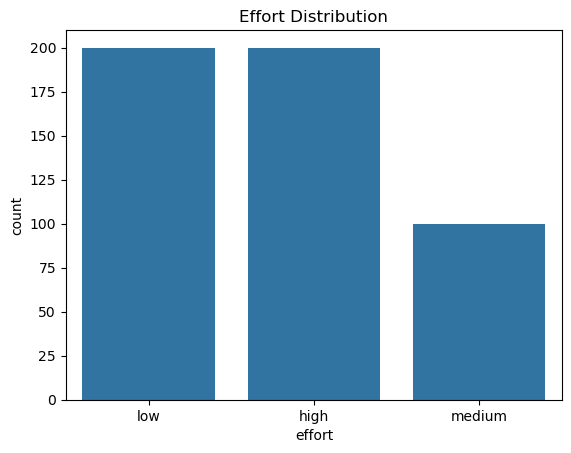

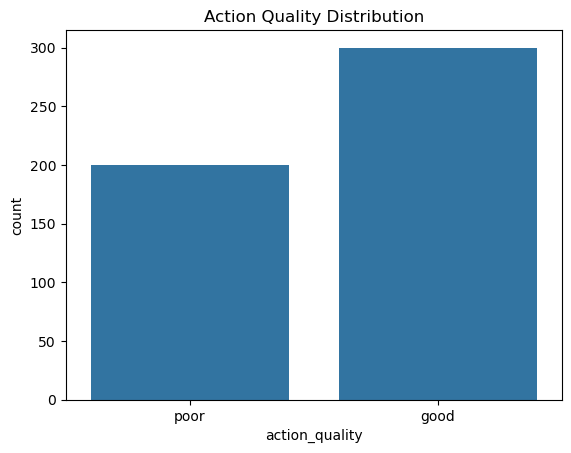

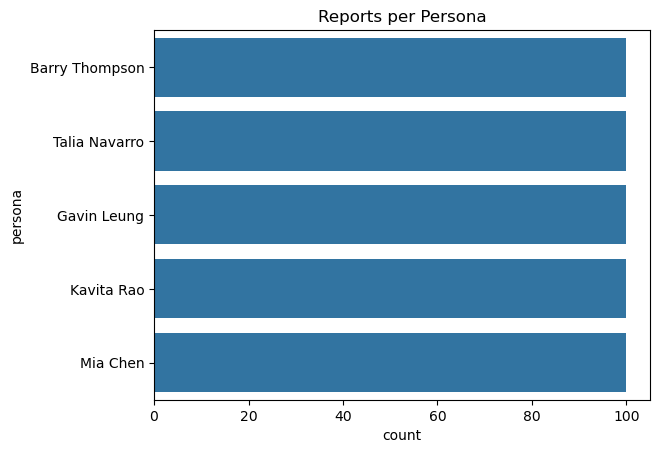

In [2]:
sns.countplot(data=df, x='effort')
plt.title('Effort Distribution')
plt.show()

sns.countplot(data=df, x='action_quality')
plt.title('Action Quality Distribution')
plt.show()

sns.countplot(data=df, y='persona', order=df['persona'].value_counts().index)
plt.title('Reports per Persona')
plt.show()

In [3]:
# TF-IDF Vectorisation and classification for effort
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X = tfidf.fit_transform(df['corrective_action'])

X_train, X_test, y_train, y_test = train_test_split(X, df['effort_encoded'], test_size=0.3, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Effort Prediction Report:\n")
print(classification_report(y_test, y_pred))

Effort Prediction Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        31
           2       1.00      1.00      1.00        54

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [4]:
# Now for action_quality
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X, df['action_quality_encoded'], test_size=0.3, random_state=42)
clf_q = LogisticRegression(max_iter=1000)
clf_q.fit(X_train_q, y_train_q)
y_pred_q = clf_q.predict(X_test_q)

print("Action Quality Prediction Report:\n")
print(classification_report(y_test_q, y_pred_q))

Action Quality Prediction Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        85

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150

